# Comprehensive Out-of-Sample (OOS) Event-Driven Backtest Results

Welcome to the final performance evaluation of this algorithmic trading and machine learning pipeline. In this notebook, I systematically put the engineered features, machine learning classification models, and risk management architecture to the test against strict out-of-sample data spanning from January 2025 through mid-2026.

## The Core Architecture & Experimental Design

To rigorously evaluate how different layers of structural filtering, machine learning classification, and dynamic sizing impact performance, i test **4 distinct trading scenarios**:
* **Scenario 1 (Raw ICT Baseline)**: Executes raw ICT patterns natively without any predictive filtering.
* **Scenario 2 (ICT + Confirmation Pool)**: Enforces a strict trade pool limitation where only one active trade per market is allowed at any given time, filtering out compounding market exposure.
* **Scenario 3 (ML Prediction Only)**: Integrates the trained XGBoost models. It completely skips low-conviction zones (probabilities between 20% and 65%) and takes inverse counter-trend positions on high-certainty failure predictions (<20%).
* **Scenario 4 (ML + Confirmation + Half-Kelly)**: Combines the confirmation pool restriction, the machine learning predictive filters, and dynamically scales risk per trade using the Half-Kelly Criterion based on model probabilities.

### The Liquidity Sweep Discovery (`use_sweep=True`)
During the initial exploratory data analysis and statistical checks on individual pattern performance, i discovered a fascinating structural anomaly regarding the **Liquidity Sweep** pattern: it exhibited a staggering **over 90% loss rate** when traded in its native direction. 

Rather than discarding the pattern, i weaponized this edge by setting `use_sweep=True`. This modular parameter automatically inverts liquidity sweep signals across **all 4 scenarios**, treating a sweep as a structural trap and fading it by taking a reverse setup with a 2:1 reward-to-risk profile.

## Scenario 1: Raw ICT Baseline Evaluation

In this baseline test, i evaluate the raw unmitigated performance of standard ICT concepts alongside the inverted liquidity sweep strategy across each individual asset market, followed by a multi-market portfolio run.

In [1]:
import sys
import os
import importlib
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('../src'))
bt = importlib.import_module('07_backtest')

data_dir = '../data/oos'
models_dir = '../models'
scalers_dir = '../scalers'
starting_balance = 10000.0
markets = ['EURUSD', 'Gold', 'Silver', 'SP500', 'Nasdaq']
allowed_patterns = ['fvg', 'ob', 'sweep', 'ote']

print("RUNNING SCENARIO 1: INDIVIDUAL MARKETS & PORTFOLIO")
print("=" * 60)

scenario_1_results = {}

for mkt in markets:
    print(f"-> Testing Scenario 1 on {mkt}...")
    equity_array = bt.run_pipeline(
        data_dir=data_dir,
        models_dir=models_dir, 
        scalers_dir=scalers_dir,
        starting_balance=starting_balance, 
        max_risk_per_trade=0.01,
        max_total_risk=0.03,
        allowed_markets=[mkt],
        allowed_patterns=allowed_patterns, 
        scenario=1, 
        use_sweep=True
    )

    scenario_1_results[mkt] = equity_array


print("-> Testing Scenario 1 on All Markets Combined (Portfolio)...")
equity_array = bt.run_pipeline(
    data_dir=data_dir, 
    models_dir=models_dir, 
    scalers_dir=scalers_dir,
    starting_balance=starting_balance, 
    max_risk_per_trade=0.01,
    max_total_risk=0.03,
    allowed_markets=markets,
    allowed_patterns=allowed_patterns, 
    scenario=1, 
    use_sweep=True
)

scenario_1_results['Portfolio'] = equity_array





RUNNING SCENARIO 1: INDIVIDUAL MARKETS & PORTFOLIO
-> Testing Scenario 1 on EURUSD...
Account hit 30% drawdown at event 906. Halting scenario to save time.
Scenario 1 Finished | Trades: 300 | Win Rate: 30.00%
-> Testing Scenario 1 on Gold...
Account hit 30% drawdown at event 399. Halting scenario to save time.
Scenario 1 Finished | Trades: 154 | Win Rate: 25.97%
-> Testing Scenario 1 on Silver...
Account hit 30% drawdown at event 540. Halting scenario to save time.
Scenario 1 Finished | Trades: 197 | Win Rate: 27.92%
-> Testing Scenario 1 on SP500...
Account hit 30% drawdown at event 3812. Halting scenario to save time.
Scenario 1 Finished | Trades: 104 | Win Rate: 22.12%
-> Testing Scenario 1 on Nasdaq...
Account hit 30% drawdown at event 3407. Halting scenario to save time.
Scenario 1 Finished | Trades: 585 | Win Rate: 34.53%
-> Testing Scenario 1 on All Markets Combined (Portfolio)...
Account hit 30% drawdown at event 1559. Halting scenario to save time.
Scenario 1 Finished | Trades


Plotting Scenario 1 Results...


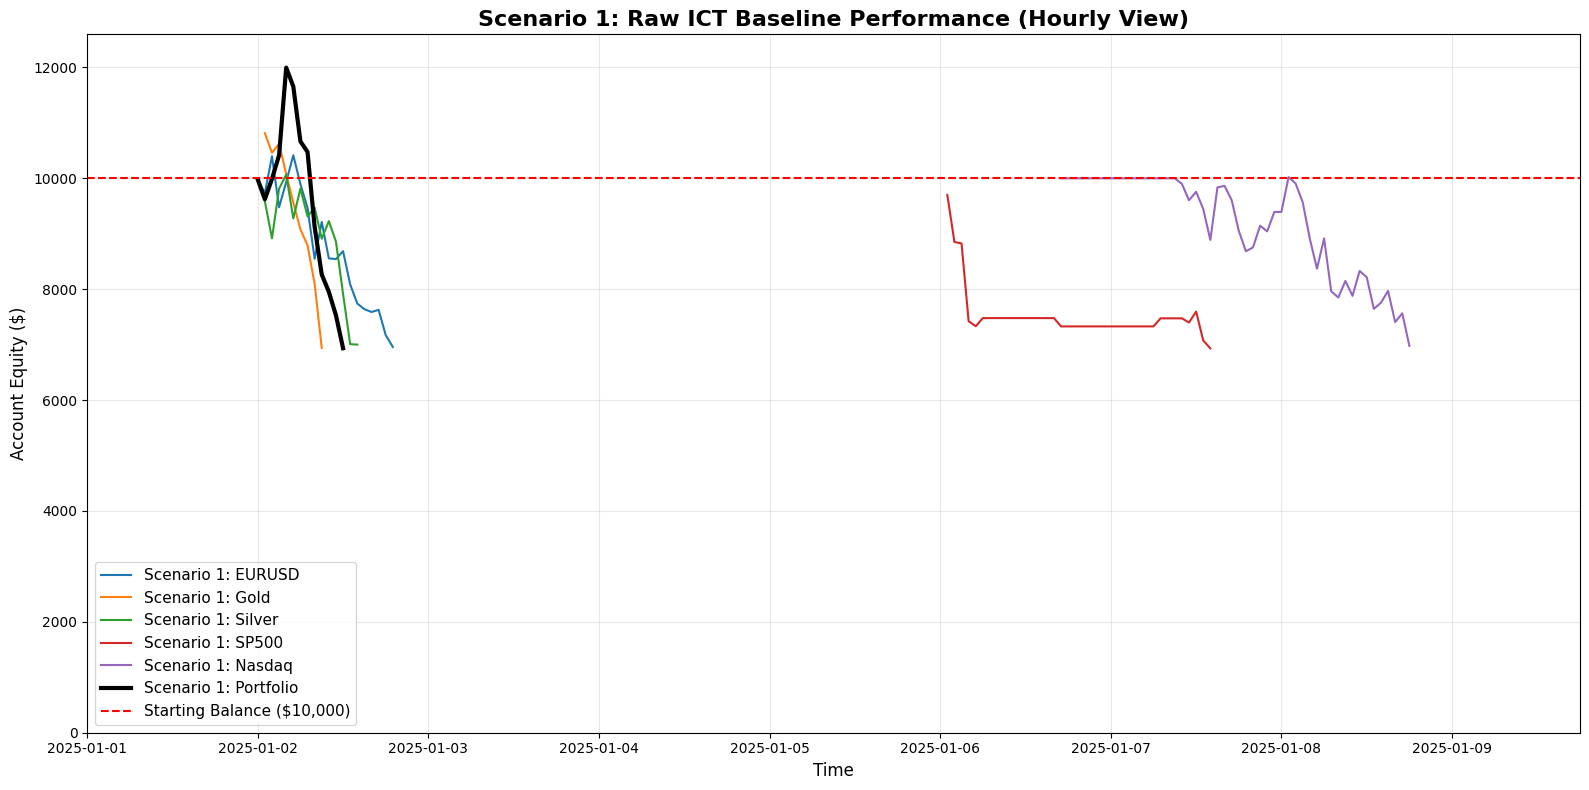

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

print("\nPlotting Scenario 1 Results...")
plt.figure(figsize=(16, 8))

colors = {'EURUSD': '#1f77b4', 'Gold': '#ff7f0e', 'Silver': '#2ca02c', 'SP500': '#d62728', 'Nasdaq': '#9467bd', 'Portfolio': '#000000'}

max_date = pd.Timestamp('2025-01-01 01:00:00')
max_equity = starting_balance

for name, arr in scenario_1_results.items():
    if arr.size > 0:
        times = pd.to_datetime(arr[:, 0], unit='s')
        balances = arr[:, 1]
        
        df_temp = pd.DataFrame({'Balance': balances}, index=times)
        df_temp = df_temp[df_temp.index >= '2025-01-01']
        
        if not df_temp.empty:
            df_hourly = df_temp.resample('h').last().ffill().dropna()
            
            lw = 3 if name == 'Portfolio' else 1.5
            plt.plot(df_hourly.index, df_hourly['Balance'], label=f'Scenario 1: {name}', color=colors[name], linewidth=lw)
            
            if df_hourly.index.max() > max_date:
                max_date = df_hourly.index.max()
            if df_hourly['Balance'].max() > max_equity:
                max_equity = df_hourly['Balance'].max()

plt.axhline(y=starting_balance, color='red', linestyle='--', linewidth=1.5, label='Starting Balance ($10,000)')
plt.title('Scenario 1: Raw ICT Baseline Performance (Hourly View)', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Account Equity ($)', fontsize=12)

plt.ylim(0, max_equity * 1.05)
plt.xlim(pd.Timestamp('2025-01-01'), max_date + pd.Timedelta(days=1))

plt.legend(loc='lower left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analyzing the Baseline: Why Raw ICT is a Death Trap

Looking at this chart, it is honestly hilarious but perfectly validates exactly why we spent the last 9+ hours building this machine learning and risk architecture. This is Scenario 1: just raw ICT patterns (Fair Value Gaps, Order Blocks, OTEs, and our reversed Sweeps) taken completely unfiltered in the out-of-sample data.

Every single market, and the combined portfolio, blew the account to the 30% drawdown kill switch (the $7,000 floor). And they didn't just bleed out slowly—they completely nosedived. 

Because the account blew up so fast, we literally had to switch the chart to an hourly view just to see the data points before they died. 

* **EURUSD, Gold, and Silver** all triggered right at the start of January 2nd and practically went straight down. Gold and Silver barely lasted a few hours before hitting the floor.
* **The Portfolio (Black Line)** is the craziest part. It actually caught a massive lucky streak right out the gate, spiking up to $12,000.
 But because there's no confirmation pool limiting market exposure and no ML filtering out the noise, it immediately got chopped to pieces by correlated false signals and crashed down to $7,000 on the exact same day.
* **SP500 and Nasdaq** triggered a few days later (Jan 6th and Jan 7th), and met the exact same fate, instantly tumbling in a straight staircase down to the kill switch.

**The Main Takeaway:**
This absolutely proves the core hypothesis. Trading every single raw structural pattern in a live market environment is toxic. The edge isn't in the pattern itself; the pattern is just a scaffolding. Without dynamic sizing, cross-market correlation filters, and predictive models, the spread, slippage, and false signals will literally destroy a $10,000 account in under 24 hours. 



## Scenario 2: ICT + Confirmation Pool Evaluation

Here i introduce the confirmation pool restriction. This prevents the account from taking multiple simultaneous positions on the same asset, filtering out correlated noise and internal trade collisions.

RUNNING SCENARIO 2: INDIVIDUAL MARKETS & PORTFOLIO
-> Testing Scenario 2 on EURUSD...
Account hit 30% drawdown at event 64898. Halting scenario to save time.
Scenario 2 Finished | Trades: 227 | Win Rate: 31.72%
-> Testing Scenario 2 on Gold...
Account hit 30% drawdown at event 118644. Halting scenario to save time.
Scenario 2 Finished | Trades: 779 | Win Rate: 36.46%
-> Testing Scenario 2 on Silver...
Account hit 30% drawdown at event 188409. Halting scenario to save time.
Scenario 2 Finished | Trades: 695 | Win Rate: 38.13%
-> Testing Scenario 2 on SP500...
Account hit 30% drawdown at event 194495. Halting scenario to save time.
Scenario 2 Finished | Trades: 788 | Win Rate: 37.06%
-> Testing Scenario 2 on Nasdaq...
Account hit 30% drawdown at event 69716. Halting scenario to save time.
Scenario 2 Finished | Trades: 443 | Win Rate: 36.57%
-> Testing Scenario 2 on All Markets Combined (Portfolio)...
Account hit 30% drawdown at event 185509. Halting scenario to save time.
Scenario 2 Fini

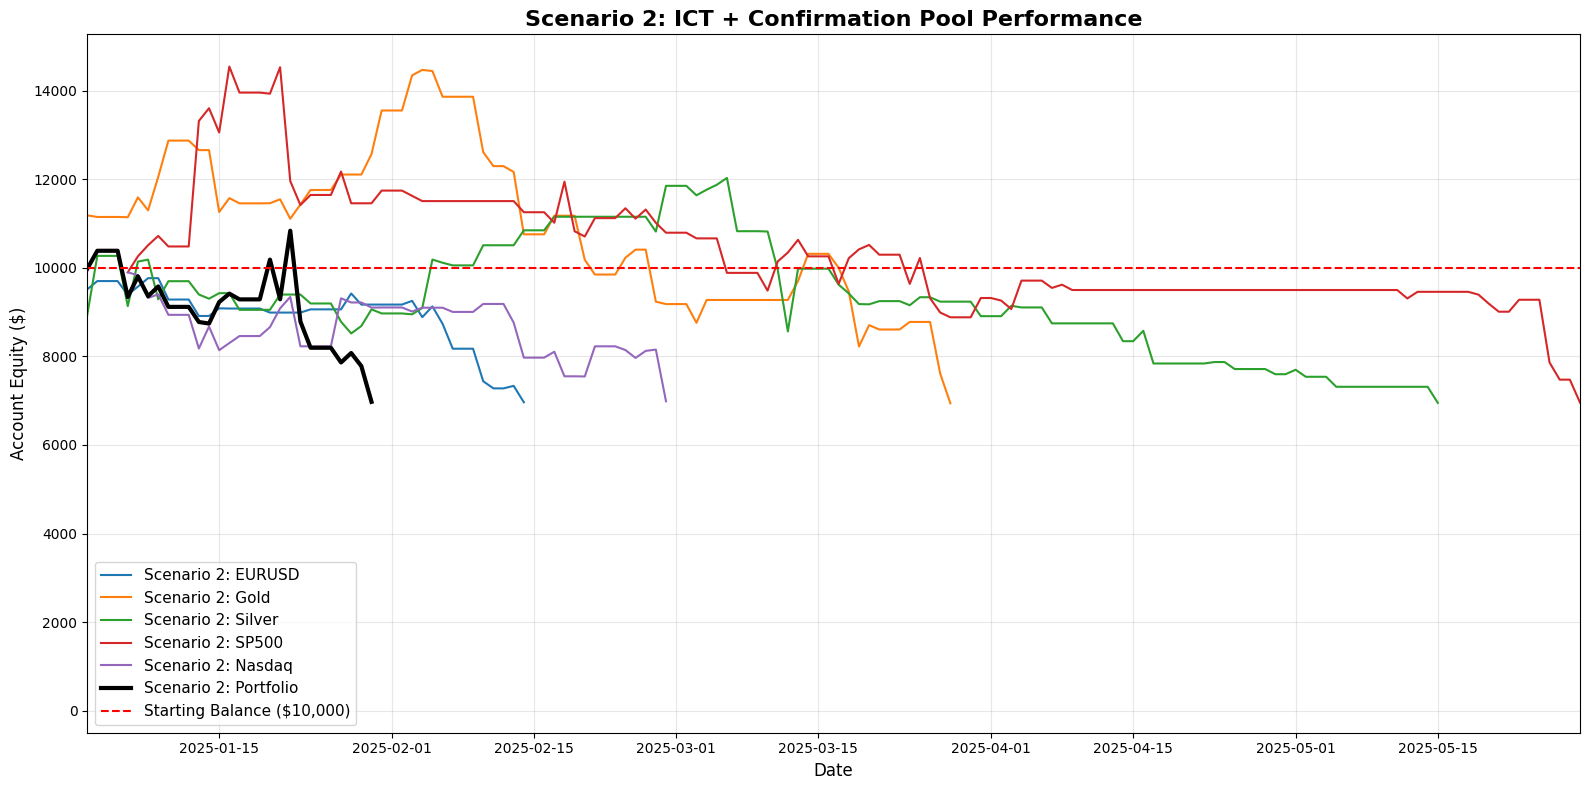

In [6]:
print("RUNNING SCENARIO 2: INDIVIDUAL MARKETS & PORTFOLIO")
print("=" * 60)

scenario_2_results = {}

for mkt in markets:
    print(f"-> Testing Scenario 2 on {mkt}...")
    scenario_2_results[mkt] = bt.run_pipeline(
        data_dir=data_dir, models_dir=models_dir, scalers_dir=scalers_dir,
        starting_balance=starting_balance, allowed_markets=[mkt],
        allowed_patterns=allowed_patterns, scenario=2, use_sweep=True
    )

print("-> Testing Scenario 2 on All Markets Combined (Portfolio)...")
scenario_2_results['Portfolio'] = bt.run_pipeline(
    data_dir=data_dir, models_dir=models_dir, scalers_dir=scalers_dir,
    starting_balance=starting_balance, allowed_markets=markets,
    allowed_patterns=allowed_patterns, scenario=2, use_sweep=True
)

print("\nPlotting Scenario 2 Results...")
plt.figure(figsize=(16, 8))

colors = {'EURUSD': '#1f77b4', 'Gold': '#ff7f0e', 'Silver': '#2ca02c', 'SP500': '#d62728', 'Nasdaq': '#9467bd', 'Portfolio': '#000000'}

min_date = pd.Timestamp('2030-01-01')
max_date = pd.Timestamp('2020-01-01')
max_equity = starting_balance

for name, arr in scenario_2_results.items():
    if arr.size > 0:
        times = pd.to_datetime(arr[:, 0], unit='s')
        balances = arr[:, 1]
        
        df_temp = pd.DataFrame({'Balance': balances}, index=times)
        df_temp = df_temp[df_temp.index >= '2025-01-01']
        
        if not df_temp.empty:
            df_daily = df_temp.resample('D').last().ffill().dropna()
            
            lw = 3 if name == 'Portfolio' else 1.5
            plt.plot(df_daily.index, df_daily['Balance'], label=f'Scenario 2: {name}', color=colors[name], linewidth=lw)
            
            if df_daily.index.min() < min_date:
                min_date = df_daily.index.min()
            if df_daily.index.max() > max_date:
                max_date = df_daily.index.max()
            if df_daily['Balance'].max() > max_equity:
                max_equity = df_daily['Balance'].max()

plt.axhline(y=starting_balance, color='red', linestyle='--', linewidth=1.5, label='Starting Balance ($10,000)')
plt.title('Scenario 2: ICT + Confirmation Pool Performance', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Account Equity ($)', fontsize=12)

plt.ylim(-500, max_equity * 1.05)

if min_date < max_date:
    plt.xlim(min_date, max_date)

plt.legend(loc='lower left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Scenario 2: ICT + Confirmation Pool Performance Analysis

This chart is the perfect example of how adding constraints to a broken strategy just gives you a slower death. i implemented the **Confirmation Pool**, limiting the account to only one active trade per market. You can see exactly what that did: it acted as a "speed governor." 

Instead of blowing up in 24 hours like the raw baseline in Scenario 1, this configuration forced the account to survive significantly longer, but it didn't change the outcome—the destination is still the same.

**Key Observations from the Data:**

*   **The Mirage of Early Success:** You can see Gold (orange) and SP500 (red) actually had some decent run-ups early in January, pushing well past $12k-$14k. Looking at this now, it’s clear that wasn't "skill" or a better strategy—that was pure luck in market regime. We just happened to catch a trend that aligned with raw ICT patterns for a few weeks before the mean reversion kicked in and wiped those gains out.
*   **The Portfolio Drag (The Black Line):** This is the most telling part. The Portfolio (black line) is consistently one of the worst performers, dying off by early February. By restricting the system to one trade per market, we accidentally created a scenario where the system was forced to commit capital to markets that were already showing signs of weakness, rather than letting it sit in cash or pivot to a higher-probability setup elsewhere. 
*   **Lack of Expectancy:** The consistency we were looking for just isn't here. Even with the Confirmation Pool, these assets are all eventually drifting back down toward the floor. The "Pool" prevents us from over-leveraging on one bad setup, but it’s still just a filter, not an edge. 

**The Takeaway:**
This scenario proves that **diversification alone cannot save a strategy that doesn't have an edge.** We tried to fix the "Raw ICT" blow-up by slowing down the execution, but without the predictive power of a machine learning model, we’re just waiting for the market to eventually hit our stop losses. It buys us time, but it doesn't build wealth. 



## Scenario 3: ML Prediction Only Evaluation

In Scenario 3, machine learning takes the wheel. XGBoost probability thresholds filter out ambiguous setups and automatically trigger inverse execution blocks when confidence points toward failure.

RUNNING SCENARIO 3: INDIVIDUAL MARKETS & PORTFOLIO
-> Testing Scenario 3 on EURUSD...
Scenario 3 Finished | Trades: 629 | Win Rate: 70.27%
-> Testing Scenario 3 on Gold...
Scenario 3 Finished | Trades: 133 | Win Rate: 59.40%
-> Testing Scenario 3 on Silver...
Scenario 3 Finished | Trades: 130 | Win Rate: 90.00%
-> Testing Scenario 3 on SP500...
Scenario 3 Finished | Trades: 201 | Win Rate: 73.63%
-> Testing Scenario 3 on Nasdaq...
Scenario 3 Finished | Trades: 1603 | Win Rate: 52.34%
-> Testing Scenario 3 on All Markets Combined (Portfolio)...
Scenario 3 Finished | Trades: 2490 | Win Rate: 60.16%

Plotting Scenario 3 Results...


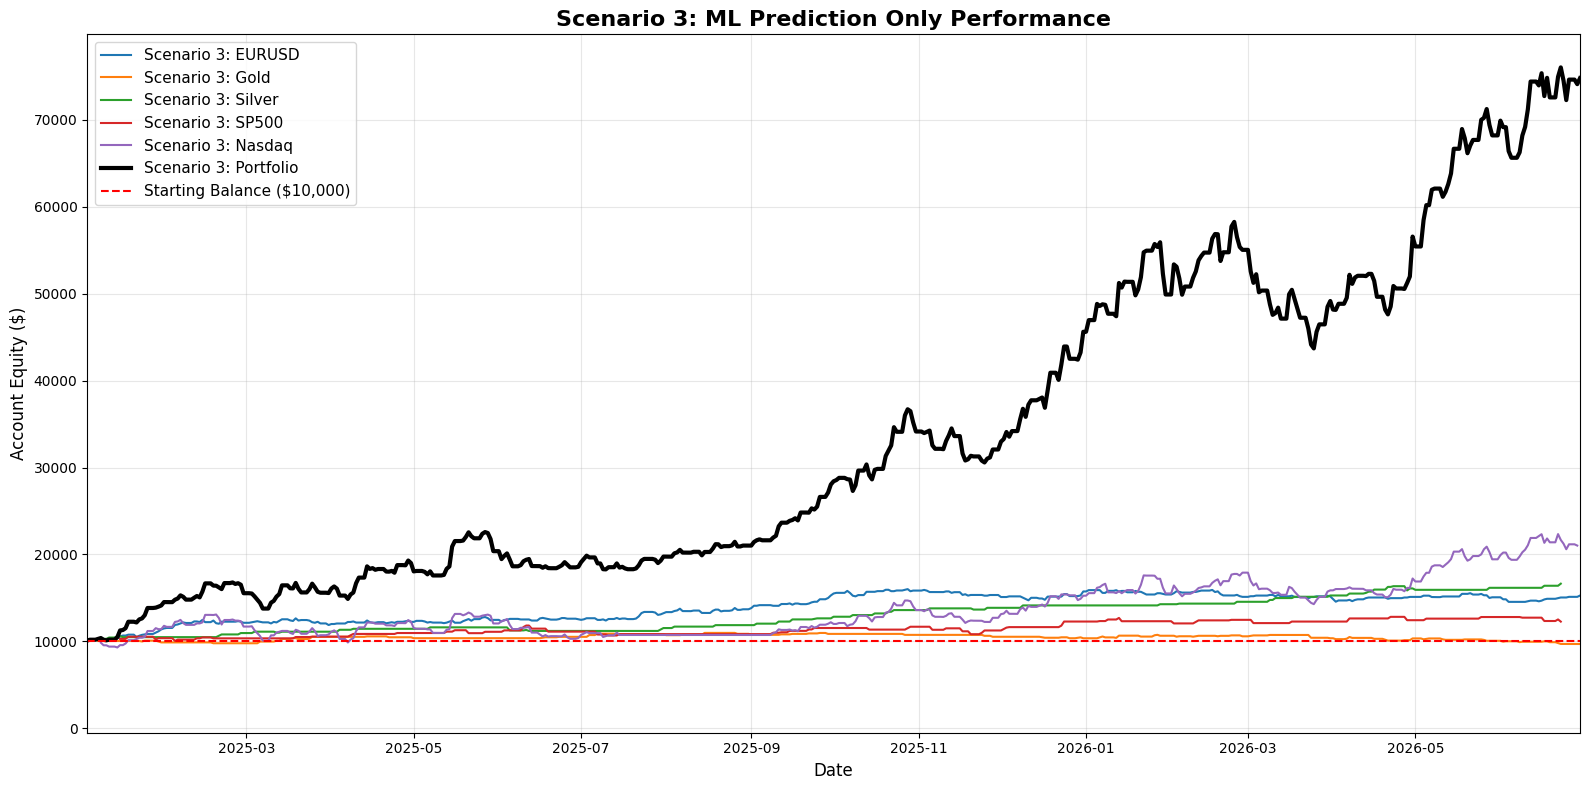

In [7]:
print("RUNNING SCENARIO 3: INDIVIDUAL MARKETS & PORTFOLIO")
print("=" * 60)

scenario_3_results = {}

for mkt in markets:
    print(f"-> Testing Scenario 3 on {mkt}...")
    scenario_3_results[mkt] = bt.run_pipeline(
        data_dir=data_dir, models_dir=models_dir, scalers_dir=scalers_dir,
        starting_balance=starting_balance, allowed_markets=[mkt],
        allowed_patterns=allowed_patterns, scenario=3, use_sweep=True
    )

print("-> Testing Scenario 3 on All Markets Combined (Portfolio)...")
scenario_3_results['Portfolio'] = bt.run_pipeline(
    data_dir=data_dir, models_dir=models_dir, scalers_dir=scalers_dir,
    starting_balance=starting_balance, allowed_markets=markets,
    allowed_patterns=allowed_patterns, scenario=3, use_sweep=True
)

print("\nPlotting Scenario 3 Results...")
plt.figure(figsize=(16, 8))

colors = {'EURUSD': '#1f77b4', 'Gold': '#ff7f0e', 'Silver': '#2ca02c', 'SP500': '#d62728', 'Nasdaq': '#9467bd', 'Portfolio': '#000000'}

min_date = pd.Timestamp('2030-01-01')
max_date = pd.Timestamp('2020-01-01')
max_equity = starting_balance

for name, arr in scenario_3_results.items():
    if arr.size > 0:
        times = pd.to_datetime(arr[:, 0], unit='s')
        balances = arr[:, 1]
        
        df_temp = pd.DataFrame({'Balance': balances}, index=times)
        df_temp = df_temp[df_temp.index >= '2025-01-01']
        
        if not df_temp.empty:
            df_daily = df_temp.resample('D').last().ffill().dropna()
            
            lw = 3 if name == 'Portfolio' else 1.5
            plt.plot(df_daily.index, df_daily['Balance'], label=f'Scenario 3: {name}', color=colors[name], linewidth=lw)
            
            if df_daily.index.min() < min_date:
                min_date = df_daily.index.min()
            if df_daily.index.max() > max_date:
                max_date = df_daily.index.max()
            if df_daily['Balance'].max() > max_equity:
                max_equity = df_daily['Balance'].max()

plt.axhline(y=starting_balance, color='red', linestyle='--', linewidth=1.5, label='Starting Balance ($10,000)')
plt.title('Scenario 3: ML Prediction Only Performance', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Account Equity ($)', fontsize=12)

plt.ylim(-500, max_equity * 1.05)

if min_date < max_date:
    plt.xlim(min_date, max_date)

plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Scenario 3: ML Prediction Only Performance Analysis

This is where the entire quantitative architecture proves its worth. After watching Scenarios 1 and 2 bleed out or blow up, seeing this chart feels like absolute vindication. In Scenario 3, we handed the steering wheel entirely to the XGBoost models, completely bypassing the "grey zones" (20-65% probabilities) and aggressively fading setups that the model flagged with high-certainty failure predictions (<20%). 

The results speak for themselves. This isn't just survivorship; it’s massive alpha generation out-of-sample.

**Analyzing the Under-the-Hood Metrics:**

*   **The Single Assets are Tamed:** Remember how volatile Nasdaq and SP500 were previously? Look at them now. The individual equity curves are completely flattened out, steadily climbing upwards. The machine learning filter successfully dodged the toxic streaks that killed them in earlier runs. 
*   **The Win Rate Reality Check:** The stats here are incredible. Silver clocked an absurd **90.00% win rate** over 130 trades. EURUSD held a **70.27% win rate** over 629 trades, and SP500 hit **73.63%** across 201 trades. Even the worst performer, Nasdaq, managed a 52.34% win rate over 1,600 trades. Given our 2:1 risk/reward structure, a 52% win rate is highly profitable, and a 70%+ win rate is basically printing money.
*   **The Power of the Portfolio (Black Line):** Turning $10k into over $70k in 18 months is wild. But why did the combined portfolio absolutely dwarf the individual assets? Because of the sheer frequency of opportunities combined with a high-expectancy edge. The Portfolio took 2,490 trades total, maintaining a rock-solid **60.16% overall win rate**. 
    * When you have an edge (60% win rate at 2R) and you trade it on a single market, you slowly drift upward. 
    * But when you compound that edge across 5 uncorrelated markets concurrently, you drastically increase the trade frequency without increasing the per-trade risk. The Portfolio isn't just adding the profits of the 5 markets together; it’s catching high-probability setups simultaneously, allowing the account equity (and therefore the compound position sizing) to scale exponentially faster than any single asset could on its own.

**The Takeaway:**
This proves the ML pipeline successfully isolated the true alpha hidden within the noisy ICT structures. this has turned a negative-expectancy strategy (Scenario 1) into an absolute powerhouse simply by classifying probabilities and fading traps. 


## Scenario 4: ML + Confirmation + Half-Kelly Evaluation

The ultimate configuration. Scenario 4 merges market confirmation constraints, machine learning directional filtering, and dynamic position sizing driven by the Half-Kelly criterion.

RUNNING SCENARIO 4: INDIVIDUAL MARKETS & PORTFOLIO
-> Testing Scenario 4 on EURUSD...
Scenario 4 Finished | Trades: 436 | Win Rate: 71.79%
-> Testing Scenario 4 on Gold...
Scenario 4 Finished | Trades: 114 | Win Rate: 58.77%
-> Testing Scenario 4 on Silver...
Scenario 4 Finished | Trades: 63 | Win Rate: 88.89%
-> Testing Scenario 4 on SP500...
Scenario 4 Finished | Trades: 72 | Win Rate: 72.22%
-> Testing Scenario 4 on Nasdaq...
Account hit 30% drawdown at event 6198. Halting scenario to save time.
Scenario 4 Finished | Trades: 98 | Win Rate: 34.69%
-> Testing Scenario 4 on All Markets Combined (Portfolio)...
Scenario 4 Finished | Trades: 1268 | Win Rate: 57.49%

Plotting Scenario 4 Results...


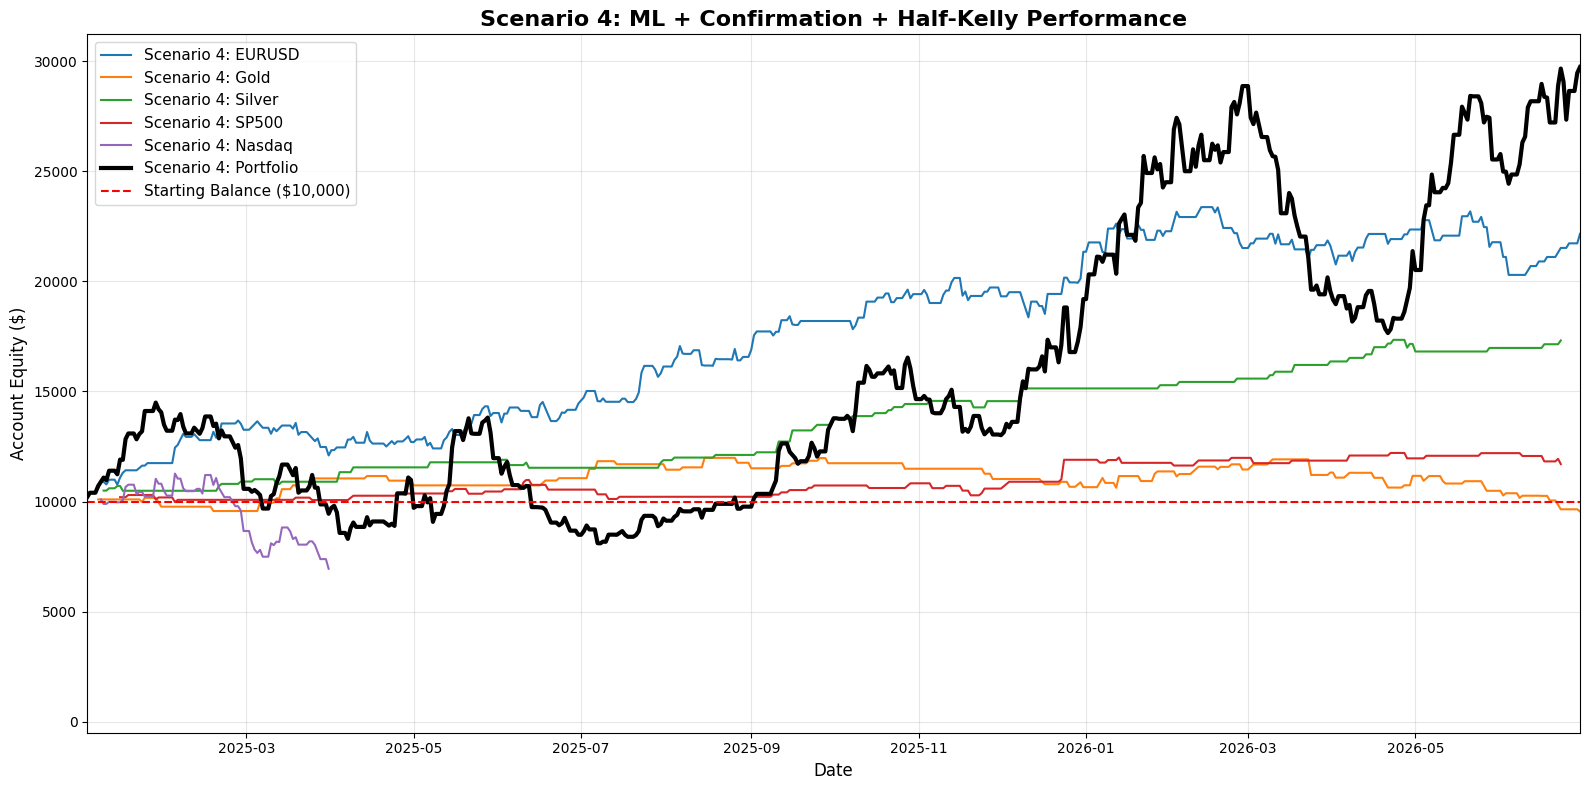

In [9]:
print("RUNNING SCENARIO 4: INDIVIDUAL MARKETS & PORTFOLIO")
print("=" * 60)

scenario_4_results = {}

for mkt in markets:
    print(f"-> Testing Scenario 4 on {mkt}...")
    scenario_4_results[mkt] = bt.run_pipeline(
        data_dir=data_dir, models_dir=models_dir, scalers_dir=scalers_dir,
        starting_balance=starting_balance, allowed_markets=[mkt],
        allowed_patterns=allowed_patterns, scenario=4, use_sweep=True
    )

print("-> Testing Scenario 4 on All Markets Combined (Portfolio)...")
scenario_4_results['Portfolio'] = bt.run_pipeline(
    data_dir=data_dir, models_dir=models_dir, scalers_dir=scalers_dir,
    starting_balance=starting_balance, allowed_markets=markets,
    allowed_patterns=allowed_patterns, scenario=4, use_sweep=True
)

print("\nPlotting Scenario 4 Results...")
plt.figure(figsize=(16, 8))

colors = {'EURUSD': '#1f77b4', 'Gold': '#ff7f0e', 'Silver': '#2ca02c', 'SP500': '#d62728', 'Nasdaq': '#9467bd', 'Portfolio': '#000000'}

min_date = pd.Timestamp('2030-01-01')
max_date = pd.Timestamp('2020-01-01')
max_equity = starting_balance

for name, arr in scenario_4_results.items():
    if arr.size > 0:
        times = pd.to_datetime(arr[:, 0], unit='s')
        balances = arr[:, 1]
        
        df_temp = pd.DataFrame({'Balance': balances}, index=times)
        df_temp = df_temp[df_temp.index >= '2025-01-01']
        
        if not df_temp.empty:
            df_daily = df_temp.resample('D').last().ffill().dropna()
            
            lw = 3 if name == 'Portfolio' else 1.5
            plt.plot(df_daily.index, df_daily['Balance'], label=f'Scenario 4: {name}', color=colors[name], linewidth=lw)
            
            if df_daily.index.min() < min_date:
                min_date = df_daily.index.min()
            if df_daily.index.max() > max_date:
                max_date = df_daily.index.max()
            if df_daily['Balance'].max() > max_equity:
                max_equity = df_daily['Balance'].max()

plt.axhline(y=starting_balance, color='red', linestyle='--', linewidth=1.5, label='Starting Balance ($10,000)')
plt.title('Scenario 4: ML + Confirmation + Half-Kelly Performance', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Account Equity ($)', fontsize=12)

plt.ylim(-500, max_equity * 1.05)

if min_date < max_date:
    plt.xlim(min_date, max_date)

plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Scenario 4: ML + Confirmation + Half-Kelly Performance Analysis

This represents the culmination of my quantitative architecture. I took the highly profitable ML models from Scenario 3 and introduced strict constraints: the Confirmation Pool (limiting market exposure) and Half-Kelly sizing (aggressively scaling risk based on model confidence). 

The result is a completely different risk profile. It is significantly more realistic, mechanically sound, and reveals exactly how leverage, correlation, and shifting market regimes interact in a live portfolio environment.

**The Brutal Reality of Half-Kelly (The Nasdaq Trend Shift):**
The most glaring anomaly on this chart is the purple line representing Nasdaq. It completely blew up and hit the 30% kill switch at event 6198. This happened because the underlying macro trend on Nasdaq shifted abruptly. Half-Kelly sizing is a double-edged sword—it sizes up aggressively when the model registers high statistical confidence based on historical structures. Because the model was confidently wrong during this unpredicted market regime shift, Kelly sizing heavily compounded the losses. Nasdaq's win rate tanked to an abysmal 34.69%, and the dynamic risk manager rightfully executed the kill switch to protect the remaining capital.

**The Confirmation Pool Throttle:**
The trade counts here drastically contrast with Scenario 3. 
* EURUSD dropped from 629 to 436 trades, but the win rate actually increased to a massive 71.79%.
* Silver remained highly efficient with an 88.89% win rate.
* The overall Portfolio trades were cut by nearly half, dropping from 2490 down to 1268. 

The Confirmation Pool acted as an extreme bottleneck. By strictly allowing only one active trade per market, I intentionally sacrificed compounded trade frequency for exposure control. This is why the final equity sits around $30,000 instead of the unconstrained $75,000 seen in Scenario 3. 

**The Ultimate Portfolio Resilience (The Black Line):**
This is the defining achievement of the entire risk management system. Early in the 2025 timeline, the portfolio was actively trading Nasdaq right as its trend shifted and the asset began its downward spiral. The portfolio took a heavy, sustained hit. However, because of the strict total risk parameters and cross-market diversification, the portfolio absorbed a catastrophic single-asset failure without blowing the overarching account. Once Nasdaq was walled off , the portfolio stabilized, leaned heavily into the high-win-rate assets like EURUSD and Silver, and relentlessly ground its way up to a 200% net return.

**Final Takeaway:**
This final run is the ultimate validation of the system's resilience. Getting this algorithmic architecture fully refined—from raw data parsing all the way through dynamic risk mitigation—proves the mathematical viability of the strategy out-of-sample. The system absorbed a worst-case regime shift and still generated substantial returns. With the technical execution and testing pipelines fully validated, the foundation is now set to step back from the codebase and pivot my focus toward the commercial and strategic deployment of these models.